In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
filepath = "../datasets/wine_quality.csv"
df = pd.read_csv(filepath, sep = ";", decimal = ",")
df.dropna(inplace = True)
df = df.astype('float')
print(df.columns)
df

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6.0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6.0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6.0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6.0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6.0
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5.0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6.0
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7.0


In [3]:
import sklearn.model_selection
train, test = sklearn.model_selection.train_test_split(df, test_size=0.2)

In [4]:
def train_model(Model, data, feature_labels, target_label):
    model = Model()
    model.fit(total_features, data[target_label])
    return model

def calc(model, data, feature_labels):
    predictions = data.copy()
    
    predictions['actual'] = predictions[target_label]
    predictions['predicted'] = model.predict(predictions[feature_labels])

    predictions['error'] = predictions['predicted'] - predictions['actual']

    rmse = np.sqrt(np.mean(predictions['error'] ** 2))
    print(f"RMSE={rmse:4f}")

    return predictions[['predicted', 'actual', 'error']]

In [5]:
data = train.copy()

target_label = "pH" # "quality"
feature_labels = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar','chlorides', 'total sulfur dioxide', 'density','free sulfur dioxide',  'alcohol', "quality",'sulphates']
# 

total_features = data[feature_labels]

In [6]:
import scipy.stats

for i in range(len(feature_labels)):
    a = feature_labels[i]
    b = target_label
    r = scipy.stats.pearsonr(train[a], train[b]).statistic
    if abs(r) > 0.2:
        print(f"{r:.2f} {a}, {b}")
            
# for i in range(len(feature_labels) - 1):
#     for j in range(i + 1, len(feature_labels)):
#         a = feature_labels[i]
#         b = feature_labels[j]
#         r = scipy.stats.pearsonr(train[a], train[b]).statistic
#         if abs(r) > 0.3:
#             print(f"{r:.2f} {a}, {b}")

-0.42 fixed acidity, pH


In [7]:
from sklearn.linear_model import LinearRegression
model = train_model(LinearRegression, data, feature_labels, target_label)

# from sklearn.tree import DecisionTreeRegressor
# model = train_model(DecisionTreeRegressor, data, feature_labels, target_label)

# from sklearn.ensemble import RandomForestRegressor
# model = train_model(RandomForestRegressor, data, feature_labels, target_label)

# from sklearn.ensemble import HistGradientBoostingRegressor
# model = train_model(HistGradientBoostingRegressor, data, feature_labels, target_label)

# from sklearn.neighbors import KNeighborsRegressor
# model = train_model(KNeighborsRegressor, data, feature_labels, target_label)

# from sklearn.ensemble import GradientBoostingRegressor
# model = train_model(GradientBoostingRegressor, data, feature_labels, target_label)

# from sklearn.neural_network import MLPRegressor
# model = train_model(MLPRegressor, data, feature_labels, target_label)

# from sklearn.linear_model import HuberRegressor
# model = train_model(HuberRegressor, data, feature_labels, target_label)


RMSE=0.094639
RMSE=0.135526


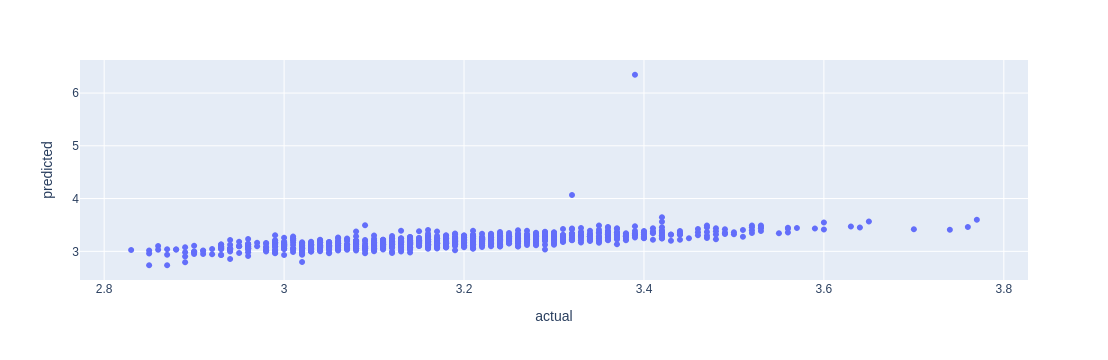

In [8]:
train_pred = calc(model, train, feature_labels)
test_pred = calc(model, test, feature_labels)
fig = px.scatter(test_pred, x = 'actual', y = 'predicted')
fig.show()